In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchmetrics.image.fid import FrechetInceptionDistance
from pytorch_lightning.callbacks import ModelCheckpoint
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
from pytorch_lightning.loggers import TensorBoardLogger
torch.set_float32_matmul_precision('high')
%load_ext tensorboard

#### DATA IMPORT AND PREPROCESSING

In [3]:
generator = torch.Generator().manual_seed(42)

trf = transforms.Compose([
    transforms.ToTensor(), # map 255 channel values in [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # map the [0,1] interval in [-1,1] this is done so the data are 0 centered and we can avoid to use the sigmoid as output activation function
])

ds_tr = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=trf)
ds_te = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=trf)

batch_size = 128
val_size = 6 * batch_size 
train_size = len(ds_tr) - val_size 

ds_tr_split, ds_val_split = random_split(ds_tr, [train_size, val_size], generator=generator)

ldr_tr = DataLoader(ds_tr_split, batch_size=batch_size, shuffle=True, num_workers=5, pin_memory=True)
ldr_val = DataLoader(ds_val_split, batch_size=batch_size, shuffle=False, num_workers=4)
ldr_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
def visualize_batch(loader,n):
    batch = next(iter(loader))
    immagini = batch[0]
    img = immagini[n]
    img = (img * 0.5) + 0.5
    img = img.permute(1, 2, 0)
    plt.imshow(img.numpy())
    plt.axis('off')
    plt.show()

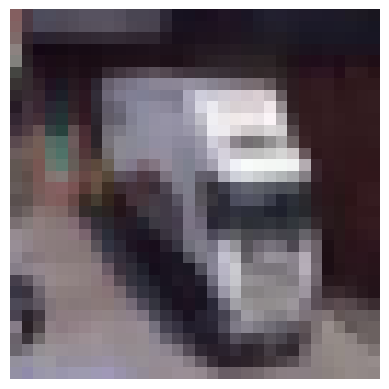

In [ ]:
visualize_batch(ldr_val,9)

#### MODEL DEFINITION

In [4]:
class WAE_GAN(pl.LightningModule):
    def __init__(self, z_dim=128, lam=10.0, ae_lr=1e-3, d_lr=1e-3):
        super().__init__()

        # the layer scaling is done following the DCGAN standard by halving the spatial size at every convolution. 
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(4*4*256, z_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh() 
        )
        self.discriminator = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2), 
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            
            nn.Linear(128, 1)
        )
        self.lam = lam
        self.ae_lr = ae_lr
        self.d_lr = d_lr
        self.z_dim = z_dim
        self.automatic_optimization = False
    
    def configure_optimizers(self):
        # the betas are used to modify the force of the momentum in oder to better follow the complex dinamics of a loss based on a network whos beeing trained alongside
        opt_ae = torch.optim.Adam(list(self.encoder.parameters()) + list(self.decoder.parameters()), lr=self.ae_lr, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(self.discriminator.parameters(), lr=self.d_lr, betas=(0.5, 0.999))
        return opt_ae, opt_d
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def sample(self,num_smpl):
        z = torch.randn(num_smpl, self.z_dim).to(self.device)
        return self.decoder(z)

    def training_step(self, batch, batch_idx):
        # get image and optimizator
        x, _ = batch
        opt_ae, opt_d = self.optimizers()

        # forward pass
        z_q = self.encoder(x)
        x_rec = self.decoder(z_q)
        z_p = torch.randn_like(z_q)

        # discriminator step
        y_q = self.discriminator(z_q.detach())
        y_p = self.discriminator(z_p)

        loss_d_q = F.binary_cross_entropy_with_logits(y_q, torch.zeros_like(y_q))
        loss_d_p = F.binary_cross_entropy_with_logits(y_p, torch.ones_like(y_p))
        loss_d = (loss_d_q + loss_d_p) / 2

        opt_d.zero_grad()
        self.manual_backward(loss_d)
        opt_d.step()

        # ae step
        y_ae_q = self.discriminator(z_q)

        loss_rec = F.mse_loss(x_rec, x)
        loss_gan = F.binary_cross_entropy_with_logits(y_ae_q, torch.ones_like(y_ae_q))
        loss_ae = loss_rec + self.lam * loss_gan

        opt_ae.zero_grad()
        self.manual_backward(loss_ae)
        opt_ae.step()

        self.log_dict({'d_loss': loss_d, 'ae_loss': loss_ae, 'recon_loss': loss_rec})

class FIDCallback(pl.Callback):
    def __init__(self, val_loader, smpl):
        super().__init__()
        self.val_loader = val_loader
        self.smpl = smpl

    def on_train_epoch_end(self, trainer, pl_module):
        fid_score, img_vis = compute_fid_score(pl_module, self.val_loader, self.smpl, pl_module.device)
        pl_module.log("val_fid", fid_score, on_step=False, on_epoch=True, prog_bar=False)
        grid = torchvision.utils.make_grid(img_vis, nrow=4) 
        trainer.logger.experiment.add_image("generated_images", grid, global_step=trainer.global_step)
        pl_module.train()

def compute_fid_score(model, loader, num_samples, device, batch_size=128):
    model.eval()
    model.to(device)
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    
    img_vis = []
    
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            curr_batch_size = min(batch_size, num_samples - i)
            img_gen_batch = model.sample(num_smpl=curr_batch_size)
            img_gen_batch = ((img_gen_batch * 0.5 + 0.5) * 255).to(torch.uint8)
            if len(img_vis) < 16:
                needed = 16 - len(img_vis)
                img_vis.append(img_gen_batch[:needed].cpu())
            fid_metric.update(img_gen_batch, real=False)
            
        for img, _ in loader:
            img = img.to(device)
            img = ((img * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(img, real=True)
            
    img_vis_tensor = torch.cat(img_vis, dim=0) if img_vis else torch.empty(0)
            
    return fid_metric.compute(), img_vis_tensor[:16]

def compute_sharpness_score(img, device):
    laplacian_kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3).to(device)
    sharpness_scores = []

    with torch.no_grad():
        gray = (0.299 * img[:, 0:1, :, :] + 
                0.587 * img[:, 1:2, :, :] + 
                0.114 * img[:, 2:3, :, :])
        
        laplacian = F.conv2d(gray, laplacian_kernel, padding=1)
        var = laplacian.view(laplacian.size(0), -1).var(dim=1)
        sharpness_scores.append(var.mean().item())    
    return sum(sharpness_scores) / len(sharpness_scores)


#### MODEL TRAINING

In [ ]:
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

model = WAE_GAN(z_dim=128, lam=1.0, ae_lr=1e-3, d_lr=1e-5)
logger = TensorBoardLogger("tb_logs", name="wae_gan_run")
ckpt_callback = ModelCheckpoint(monitor='val_fid', mode='min', save_top_k=1, filename='best-model-drop_smooth', dirpath=ckpt_dir)
fid_callback = FIDCallback(val_loader=ldr_val, smpl=768)
trainer = pl.Trainer(max_epochs=500, callbacks=[ckpt_callback,fid_callback], accelerator="auto", devices=1, logger=logger, enable_progress_bar=False, enable_model_summary=False)

trainer.fit(model, ldr_tr)

#### MODEL TEST

In [6]:
best_model = WAE_GAN.load_from_checkpoint("checkpoints/best-model-drop_smooth.ckpt")
FID_test, _ = compute_fid_score(best_model, ldr_te, num_samples=len(ldr_te)*128, device='cuda')
sharp_test = compute_sharpness_score(best_model.sample(1000), 'cuda')
sharp_real = np.mean([compute_sharpness_score(batch.to('cuda'), 'cuda') for batch, _ in ldr_te])
print(f"FID on test: {FID_test}")
print(f'Sharpness on test: {sharp_test}    Sharpness on real:{sharp_real}')

FID on test: 95.16541290283203
Sharpness on test: 0.11174444854259491    Sharpness on real:0.17756999708429166


#### VISUALIZATION

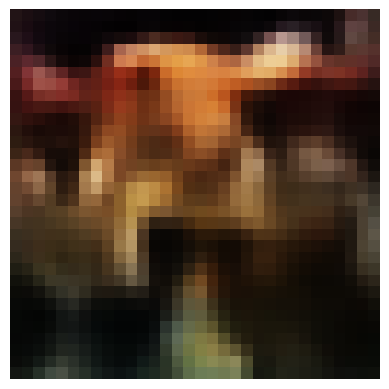

In [46]:
img = best_model.sample(1).detach().squeeze().cpu()
img = (img * 0.5) + 0.5
img = img.permute(1, 2, 0)
plt.imshow(img.numpy())
plt.axis('off')
plt.show()

In [ ]:
def visualize_reconstructions(model, dataloader, device, num_images=5):
    model.eval() 
    model.to(device)
    images, _ = next(iter(dataloader))
    
    images = images[:num_images].to(device)

    with torch.no_grad():
        reconstructions = model(images)
    images = images.cpu()
    reconstructions = reconstructions.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))
    fig.suptitle("Comparison: Original images vs Recostructed", fontsize=16)

    for i in range(num_images):
        img_orig = (images[i] * 0.5) + 0.5
        img_orig = img_orig.permute(1, 2, 0).numpy()
        axes[0, i].imshow(img_orig)
        axes[0, i].set_title(f"Originale {i+1}")
        axes[0, i].axis('off') 
        img_recon = (reconstructions[i] * 0.5) + 0.5
        img_recon = img_recon.permute(1, 2, 0).numpy()
        axes[1, i].imshow(img_recon)
        axes[1, i].set_title(f"Reconstructed {i+1}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

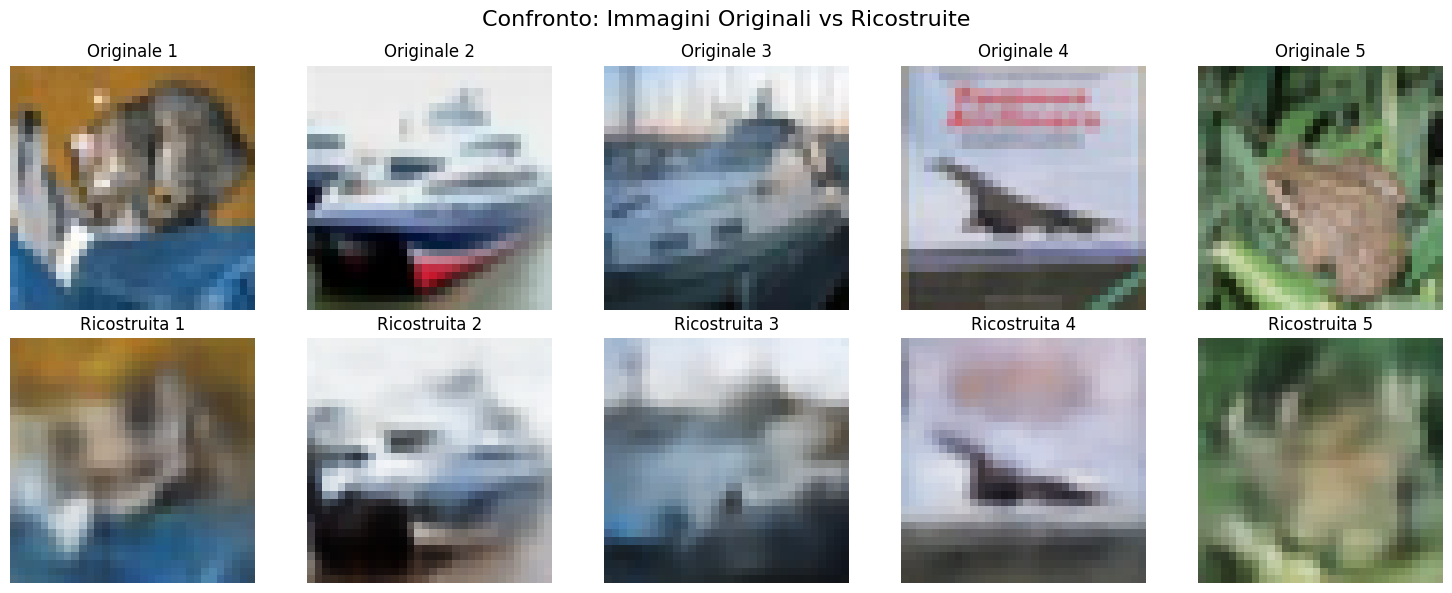

In [8]:
best_model = WAE_GAN.load_from_checkpoint("checkpoints/best-model-drop_smooth.ckpt")
visualize_reconstructions(best_model, ldr_te, device='cuda', num_images=5)

#### CALEB A TEST

In [3]:
class WAE_GAN_FACE(pl.LightningModule):
    def __init__(self, z_dim=128, lam=10.0, ae_lr=1e-3, d_lr=1e-3):
        super().__init__()

        # the layer scaling is done following the DCGAN standard by halving the spatial size at every convolution. 
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            
            nn.Flatten(),
            nn.Linear(4 * 4 * 512, z_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 512 * 4 * 4),
            nn.Unflatten(1, (512, 4, 4)),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
 
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh() 
        )
        self.discriminator = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2), 
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            
            nn.Linear(128, 1)
        )
        self.lam = lam
        self.ae_lr = ae_lr
        self.d_lr = d_lr
        self.z_dim = z_dim
        self.automatic_optimization = False
    
    def configure_optimizers(self):
        # the betas are used to modify the force of the momentum in oder to better follow the complex dinamics of a loss based on a network whos beeing trained alongside
        opt_ae = torch.optim.Adam(list(self.encoder.parameters()) + list(self.decoder.parameters()), lr=self.ae_lr, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(self.discriminator.parameters(), lr=self.d_lr, betas=(0.5, 0.999))
        return opt_ae, opt_d
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def sample(self,num_smpl):
        z = torch.randn(num_smpl, self.z_dim).to(self.device)
        return self.decoder(z)

    def training_step(self, batch, batch_idx):
        # get image and optimizator
        x, _ = batch
        opt_ae, opt_d = self.optimizers()

        # forward pass
        z_q = self.encoder(x)
        x_rec = self.decoder(z_q)
        z_p = torch.randn_like(z_q)

        # discriminator step
        y_q = self.discriminator(z_q.detach())
        y_p = self.discriminator(z_p)

        loss_d_q = F.binary_cross_entropy_with_logits(y_q, torch.zeros_like(y_q))
        loss_d_p = F.binary_cross_entropy_with_logits(y_p, torch.ones_like(y_p))
        loss_d = (loss_d_q + loss_d_p) / 2

        opt_d.zero_grad()
        self.manual_backward(loss_d)
        opt_d.step()

        # ae step
        y_ae_q = self.discriminator(z_q)

        loss_rec = F.mse_loss(x_rec, x)
        loss_gan = F.binary_cross_entropy_with_logits(y_ae_q, torch.ones_like(y_ae_q))
        loss_ae = loss_rec + self.lam * loss_gan

        opt_ae.zero_grad()
        self.manual_backward(loss_ae)
        opt_ae.step()

        self.log_dict({'d_loss': loss_d, 'ae_loss': loss_ae, 'recon_loss': loss_rec})


In [4]:
transform_faces = transforms.Compose([transforms.CenterCrop(140), transforms.Resize((64, 64)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

root_dir = './data/celeba'

dataset_train = torchvision.datasets.ImageFolder(root=f'{root_dir}/train', transform=transform_faces)
dataset_valid = torchvision.datasets.ImageFolder(root=f'{root_dir}/val', transform=transform_faces)
dataset_test  = torchvision.datasets.ImageFolder(root=f'{root_dir}/test', transform=transform_faces)

ldr_tr = DataLoader(dataset_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
ldr_val = DataLoader(dataset_valid, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
ldr_te = DataLoader(dataset_test, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [5]:
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

model = WAE_GAN_FACE(z_dim=128, lam=1.0, ae_lr=1e-3, d_lr=1e-5)
logger = TensorBoardLogger("tb_logs", name="wae_face_run")
ckpt_callback = ModelCheckpoint(monitor='val_fid', mode='min', save_top_k=1, filename='best-model-face', dirpath=ckpt_dir)
fid_callback = FIDCallback(val_loader=ldr_val, smpl=768)
trainer = pl.Trainer(max_epochs=500, callbacks=[ckpt_callback,fid_callback], accelerator="auto", devices=1, logger=logger, enable_progress_bar=False, enable_model_summary=False)

trainer.fit(model, ldr_tr)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/pietro/.my_envs/machine_learning/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/pietro/universita/Prob_ML/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pietro/.my_envs/machine_learning/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=500` reached.


In [ ]:
best_model = WAE_GAN_FACE.load_from_checkpoint("checkpoints/best-model-deep.ckpt")
FID_test, _ = compute_fid_score(best_model, ldr_te, num_samples=len(ldr_te)*128, device='cuda')
sharp_test = compute_sharpness_score(best_model.sample(1000), 'cuda')
sharp_real = np.mean([compute_sharpness_score(batch.to('cuda'), 'cuda') for batch, _ in ldr_te])
print(f"FID on test: {FID_test}")
print(f'Sharpness on test: {sharp_test}    Sharpness on real:{sharp_real}')

FID on test: 60.09064865112305
Sharpness on test: 0.035630907863378525    Sharpness on real:0.07700794771219949
